In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("/kaggle/input/taxi-trip-fare-data-2023/Taxi_Trip_Data_preprocessed.csv")

In [3]:
df.head()

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,3.70,Card,24.0,27.950000
1,1,2.77,Card,18.4,19.200000
2,1,3.30,Card,22.6,27.383333
3,1,0.30,Cash,5.1,2.550000
4,1,0.83,Card,7.2,5.250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8451090 entries, 0 to 8451089
Data columns (total 5 columns):
 #   Column           Dtype  
---  ------           -----  
 0   passenger_count  int64  
 1   trip_distance    float64
 2   payment_type     object 
 3   fare_amount      float64
 4   duration         float64
dtypes: float64(3), int64(1), object(1)
memory usage: 322.4+ MB


In [5]:
df.isnull().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
duration           0
dtype: int64

In [6]:
df.describe()

,passenger_count,trip_distance,fare_amount,duration
count,8.451090e+06,8.451090e+06,8.451090e+06,8.451090e+06
mean,1.339824e+00,1.751135e+00,1.273180e+01,1.173603e+01
std,7.658024e-01,1.045488e+00,5.346809e+00,6.218064e+00
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,9.700000e-01,8.600000e+00,6.900000e+00
50%,1.000000e+00,1.500000e+00,1.210000e+01,1.065000e+01
75%,1.000000e+00,2.300000e+00,1.630000e+01,1.561667e+01
max,5.000000e+00,5.230000e+00,4.080000e+01,2.995000e+01


In [7]:
df["duration"].mean()

11.73603279379741

In [8]:
## burada gözüken bazı uç noktlara var mesele 0.01 saniyelik yolculuk
## 0.01 dolar yolculuk ücreti gibi 
## bu aykırı değerleri kontrol edeceğiz.

df = df[df["duration"] > 30/60]  # 30 saniyeden uzun yolculukları tut
df = df[df["fare_amount"] > 1] ## 1 dolardan az yolculukları sil
df = df[df["trip_distance"] > 0.02] ## 0.02 milden uzunları tut

In [9]:
df.shape

(8441998, 5)

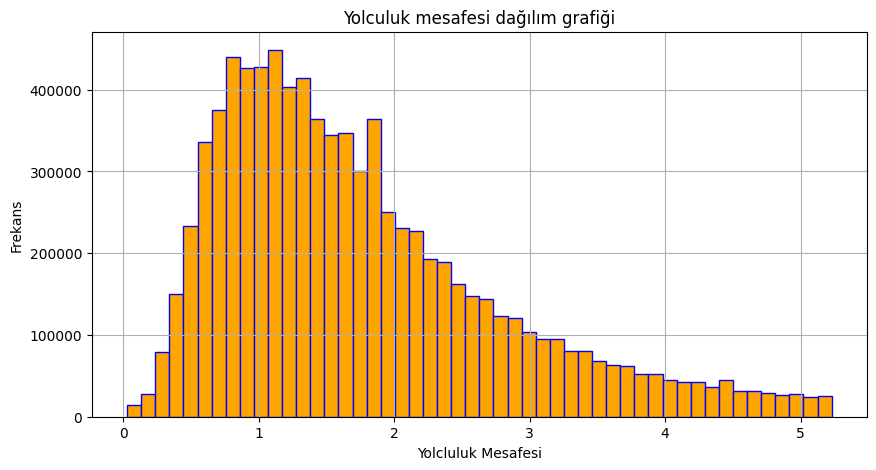

In [10]:
## yolculuk dağılımına bakalım
plt.figure(figsize=(10,5))
df["trip_distance"].hist(bins=50,color="orange", edgecolor="blue")
plt.xlabel("Yolcluluk Mesafesi")
plt.ylabel("Frekans")
plt.title("Yolculuk mesafesi dağılım grafiği")
plt.show()

Text(0.5, 1.0, 'Taksi Dağılım Ücreti')

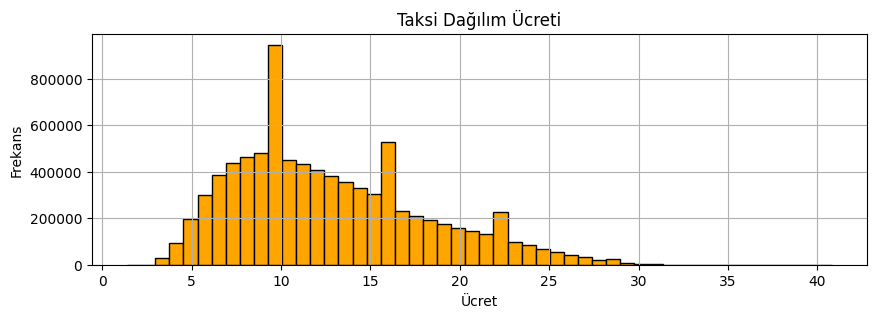

In [11]:
#ücret dağılımı
plt.figure(figsize=(10,3))
df["fare_amount"].hist(bins=50,color="orange", edgecolor="black")
plt.xlabel("Ücret")
plt.ylabel("Frekans")
plt.title("Taksi Dağılım Ücreti")


Text(0.5, 1.0, 'Yolculuk/Ücret')

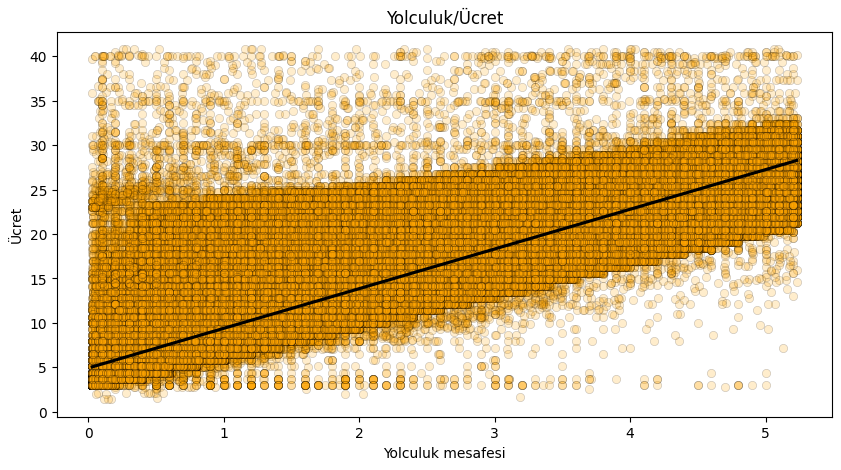

In [12]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df["trip_distance"], y=df["fare_amount"], alpha=0.2,color="orange",edgecolor="black")
sns.regplot(x=df["trip_distance"],y=df["fare_amount"],scatter=False,color="black")
plt.xlabel("Yolculuk mesafesi")
plt.ylabel("Ücret")
plt.title("Yolculuk/Ücret")

In [13]:
payment_sayisi = df["payment_type"].value_counts()

Text(0.5, 1.0, 'Ödeme türü pie grafiği')

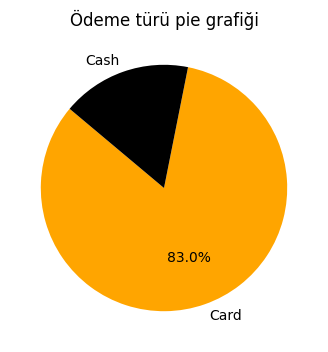

In [36]:
plt.figure(figsize=(4,4))
plt.pie(payment_sayisi, labels=payment_sayisi.index,startangle=140,
        autopct="%1.1f%%",
        colors=["orange", "black"])
plt.title("Ödeme türü pie grafiği")

In [15]:
## KORELASYONLARA BAKALIM

df_numeric = df.select_dtypes(include=["number"])  # Sadece sayısal değişkenleri seç
df_numeric.corr()


,passenger_count,trip_distance,fare_amount,duration
passenger_count,1.000000,0.017545,0.024917,0.022928
trip_distance,0.017545,1.000000,0.874085,0.705989
fare_amount,0.024917,0.874085,1.000000,0.943564
duration,0.022928,0.705989,0.943564,1.000000


Text(0.5, 1.0, 'Korelasyon Matrisi Olşutruduk')

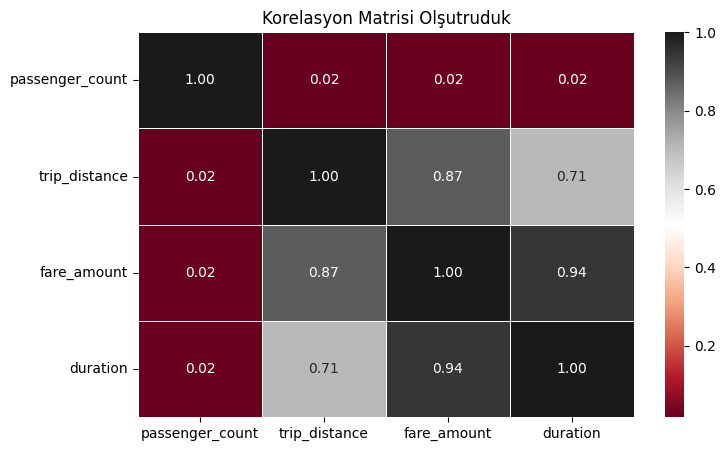

In [16]:
plt.figure(figsize=(8,5))
sns.heatmap(df_numeric.corr(), annot=True, cmap="RdGy", fmt=".2f", linewidths=0.5)
plt.title("Korelasyon Matrisi Olşutruduk")

In [17]:
##LİNEER REGRESYON

X = df_numeric[["trip_distance","duration"]]
y = df_numeric["fare_amount"]

In [18]:
X.shape,y.shape

((8441998, 2), (8441998,))

In [19]:
## Veriyi bölme 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
#lineer regresyon modeli ekleme

model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [21]:
#tahminleme yapma

y_pred = model.predict(X_test)
tahmin_df = pd.DataFrame({"Gerçek Ücret":y_test.values, "Tahmin edilen ücret:":y_pred})


In [23]:
tahmin_df.head()

,Gerçek Ücret,Tahmin edilen ücret:
0,7.2,7.163776
1,7.9,8.168187
2,13.5,12.740575
3,14.9,15.028270
4,7.9,7.717198


In [31]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [34]:
print(f"MSE:{mse}")
print(f"RMSE:{rmse}")
print(f"R_kare:{r2}")

MSE:0.6672628946337218
RMSE:0.8168616129025295
R_kare:0.9766166724970561


In [41]:
ornek = np.array([[3.70, 27.95]])
ornek_tahmin = model.predict(ornek)
print(ornek_tahmin)

[25.93108892]
